# 4.10. Interpretación de los gráficos de colores de esfuerzos y deformaciones de una viga en voladizo

Por:
- Michael Heredia Pérez
- [mherediap@unal.edu.co](mherediap@unal.edu.co)
- 2026-03-06


## El problema

En este cuaderno, vamos a realizar el análisis de los gráficos de esfuerzos y deformaciones para una viga simplemente apoyada con una carga uniformemente distriuida, como se muestra en la figura. 

<img src="figs/viga-voladizo.png" width="600">

## Librerías y funciones a utilizar

Primero, definimos algunos parámetros en la librería matplotlib para darle estilo al texto de las gráficas. 

In [27]:
import matplotlib as mpl

# Configure matplotlib for STIX font - comprehensive setup
mpl.rcParams.update({
    # Primary font configuration
    "font.family": "serif",              # Use serif family
    "font.serif": ["STIX", "STIXGeneral", "STIX Two Text"], # STIX font priority
    "mathtext.fontset": "stix",          # Math expressions in STIX
    
    # Explicit font specification for all text elements
    "axes.labelsize": 18,
    "axes.titlesize": 18, 
    "legend.fontsize": 16,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "font.size": 16,
    
    # Line properties
    "lines.linewidth": 1.5
})

In [28]:
# Importamos las librerías necesarias

import numpy as np
import matplotlib.pyplot as plt

Vamos a realizar muchas figuras, una por cada esfuerzo estudiado. Así que creamos una función para impirmir estas figuras y de ser necesario, guardarlas. 

In [29]:
# Función para graficar los esfuerzos y deformaciones.
from funciones_plot import plot_esf_def

# Función para graficar el campo escalar del esfuerzo.
from funciones_plot import plot_3d_esf_def

# Función de graficación interactiva del campo escalar del esfuerzo.
from funciones_plot import plot_3d_esf_def_interactive

# Función para graficar fuerza cortante y momento flector.
from funciones_plot import plot_v_m

## Formulación y análisis.

Definimos las constantes de nuestro problema.

In [30]:
# Propiedades geométricas de la viga.
c = 0.50    # m, altura = 2c.
L = 3.00    # m, luz    = L.
t = 1.00    # m, espesor unitario.

# Se calcula el momento de inercia centroidal I = bh^3/12, con b=1 y h=2c.
I = (t * (2*c)**3) / 12 # m^4.

# Carga aplicada
q = -10.0   # kN/m.

# Propiedades del material
E  = 21e6         # kPa = 21 GPa, módulo de Young.
nu = 0.23         # ad          , coeficiente de Poisson.
G = E/(2*(1+nu))  # kPa         , módulo de cortante.

Las funciones que determinan el estado de esfuerzos de la viga, fueron calculadas al solucionar la función de tensión de Airy. Estas ecuaciones las resolveremos en una discretización de la viga. 

In [31]:
# Se crea la grilla de puntos donde se harán los cálculos.
nnds_x = 50
nnds_y = 20
x, y = np.meshgrid( np.linspace(0, L, nnds_x), np.linspace(-c, c, nnds_y) )

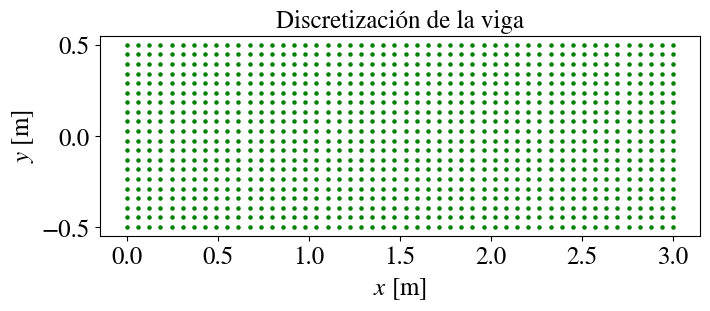

In [32]:
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.scatter(x, y, s=5, color="green")    # solo ploteamos puntos.
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]", rotation=90)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Discretización de la viga")
plt.show()

Los esfuerzos al interior de la viga estarán caracterizados por las siguientes ecuaciones:

$$\begin{align*}
\sigma_x(x, y) &= -\frac{qy\left(15L^2 - 30Lx + 6c^2 + 15x^2 - 10y^2\right)}{20c^3} \\[6pt]
\sigma_y(x, y) &= -\frac{q\left(-2c + y\right)\left(c + y\right)^2}{4c^3} \\[6pt]
\sigma_z(x, y) &= 0 \\[6pt]
\tau_{xy}(x, y) &= \frac{3q\left(-L + x\right)\left(-c + y\right)\left(c + y\right)}{4c^3} \\[6pt]
\tau_{xz}(x, y) &= 0 \\[6pt]
\tau_{yz}(x, y) &= 0
\end{align*}$$

Estas ecuaciones fueron obtenidas mediante la **función de tensión de Airy**. Vemos que la viga puede considerarse como un caso de tensión plana ($\sigma_z = \tau_{xz} = \tau_{yz} = 0$).

Dichas funciones de esfuerzos las calcularemos en cada punto discretizado de la viga. A partir de la Ley de Hooke podremos calcular las deformaciones en la viga, y consecuentemente los esfuerzos y direcciones principales.

**Nota:** El cálculo de dichas funciones se realizó en este código:
[https://github.com/diegoandresalvarez/solidos/blob/master/codigo/05_ec_diferenciales_solidos/5.15_ejer_10_viga_en_voladizo_Airy.ipynb](https://github.com/diegoandresalvarez/solidos/blob/master/codigo/05_ec_diferenciales_solidos/5.15_ejer_10_viga_en_voladizo_Airy.ipynb)

In [33]:
# Se definen los esfuerzos (en tensión plana: sz = txz = tyz = 0)
# Solución de la función de tensión de Airy para una viga en voladizo
sx  = -(q*y * (15*L**2 - 30*L*x + 6*c**2 + 15*x**2 - 10*y**2)) / (20*c**3)
sy  = -(q * (-2*c + y) * (c + y)**2) / (4*c**3)
txy =  (3*q * (-L + x) * (-c + y) * (c + y)) / (4*c**3)

# Se calculan las deformaciones.
ex  = (1/E)*(sx - nu*sy)
ey  = (1/E)*(sy - nu*sx)
ez  = -(nu/E)*(sx + sy)
gxy = txy/G

# Se calculan los esfuerzos principales, los esfuerzos cortantes máximos y sus 
# ángulos.
tmax = np.sqrt( ((sx - sy)/2)**2 + txy**2 )
s1 = (sx + sy)/2 + tmax
s2 = (sx + sy)/2 - tmax
t1 = np.arctan2(2*txy, sx-sy)/2     
t2 = t1 + np.pi/2                   # t1 + 90°

## Gráficos de esfuerzos $\sigma_x$, $\sigma_y$, $\tau_{xy}$

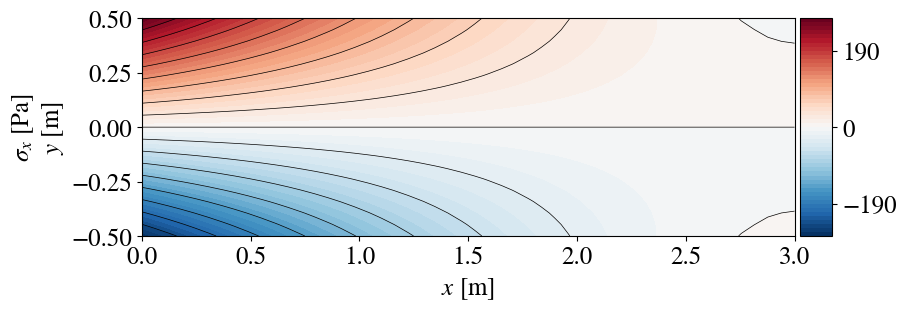

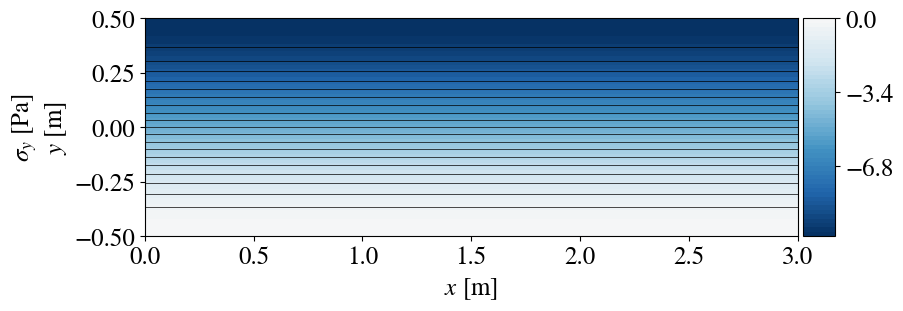

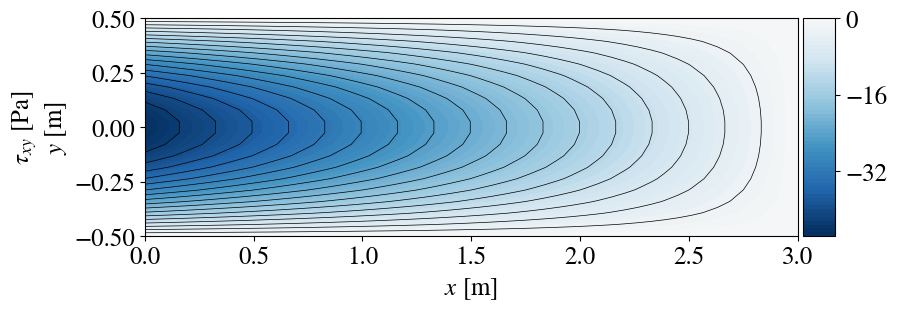

In [34]:
plot_esf_def(x, y, sx,  r"$\sigma_x$ [Pa]")
plot_esf_def(x, y, sy,  r"$\sigma_y$ [Pa]")
plot_esf_def(x, y, txy, r"$\tau_{xy}$ [Pa]")

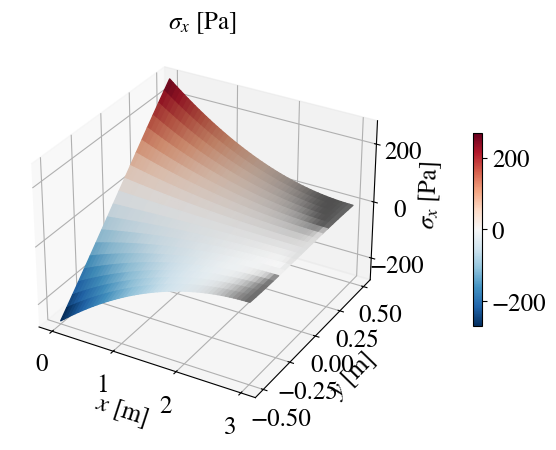

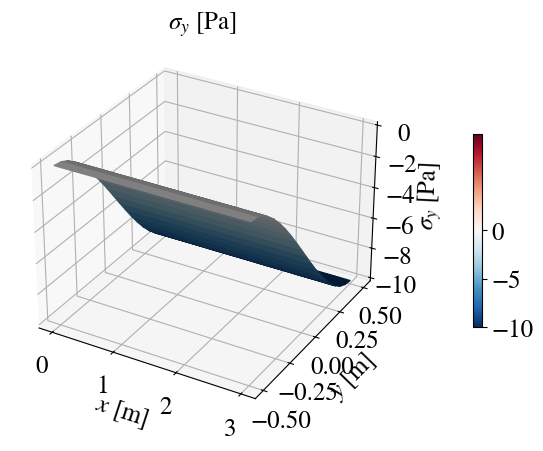

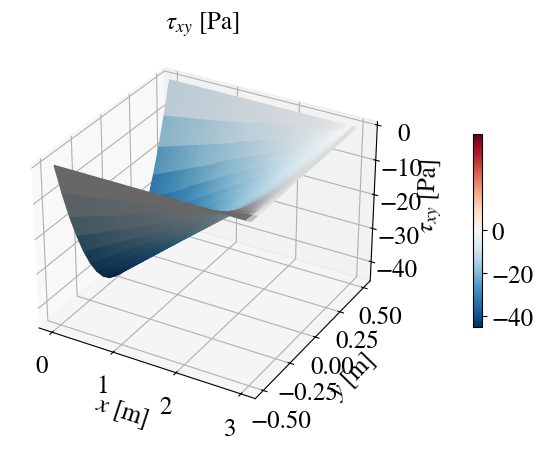

In [35]:
# Veamos ahora el campo escalar que tenemos asociado a cada esfuerzo.
plot_3d_esf_def(x, y, sx,  r"$\sigma_x$ [Pa]")
plot_3d_esf_def(x, y, sy, r"$\sigma_y$ [Pa]")
plot_3d_esf_def(x, y, txy, r"$\tau_{xy}$ [Pa]")

In [36]:
plot_3d_esf_def_interactive(x, y, sx,  r"$\sigma_x$ [Pa]")
plot_3d_esf_def_interactive(x, y, sy,  r"$\sigma_y$ [Pa]")
plot_3d_esf_def_interactive(x, y, txy, r"$\tau_{xy}$ [Pa]")

## Gráficos de deformaciones $\varepsilon_x$, $\varepsilon_y$, $\varepsilon_z$, $\gamma_{xy}$

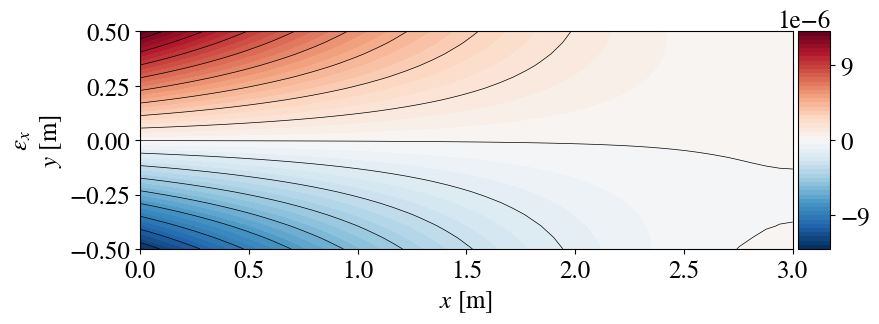

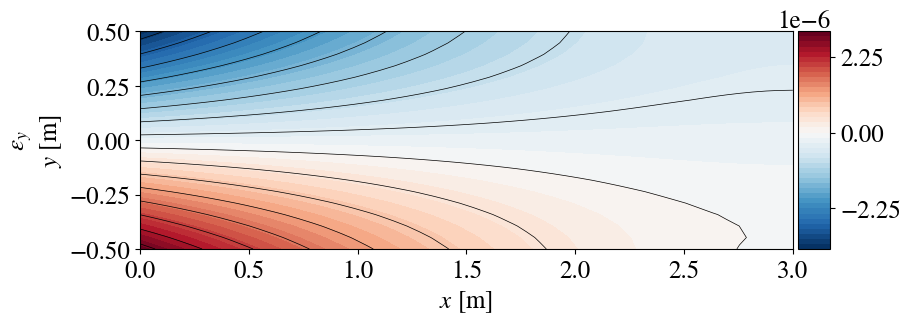

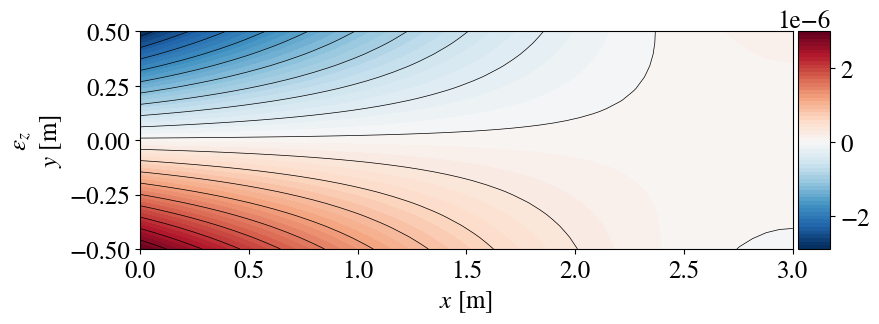

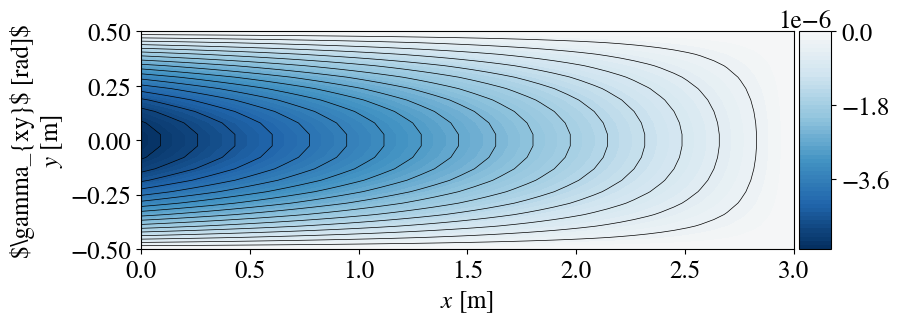

In [37]:
plot_esf_def(x, y, ex,  r"$\epsilon_x$")
plot_esf_def(x, y, ey,  r"$\epsilon_y$")
plot_esf_def(x, y, ez,  r"$\epsilon_z$")
plot_esf_def(x, y, gxy, r"$\gamma_{xy}$ [rad]$")

## Gráficos de los esfuerzos principales con sus direcciones

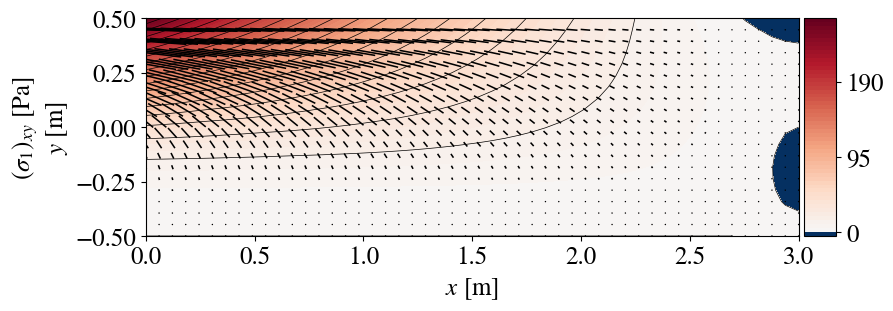

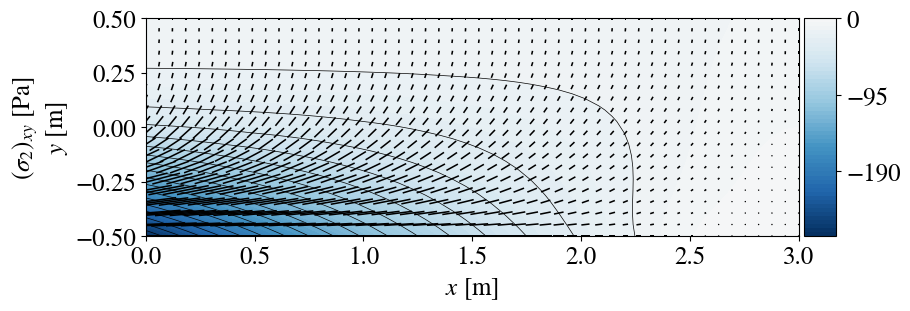

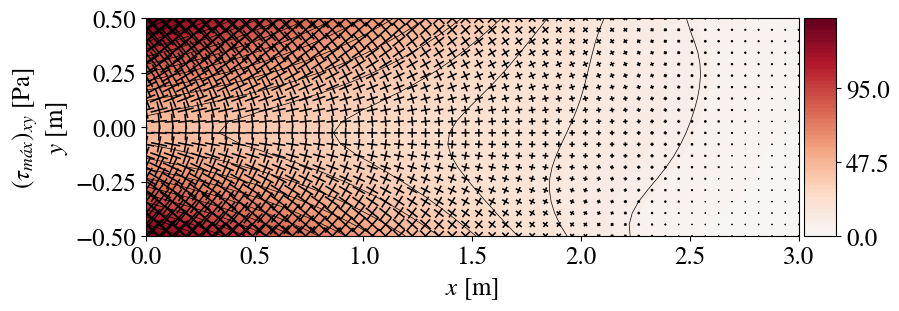

In [38]:
plot_esf_def(x, y, s1,   r"$(\sigma_1)_{xy}$ [Pa]", angulo=t1)
plot_esf_def(x, y, s2,   r"$(\sigma_2)_{xy}$ [Pa]", angulo=t2)
plot_esf_def(x, y, tmax, r"$(\tau_{máx})_{xy}$ [Pa]", angulo=[t1-np.pi/4, t1+np.pi/4])

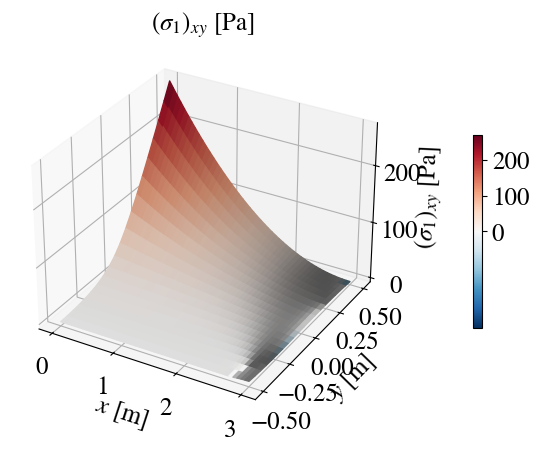

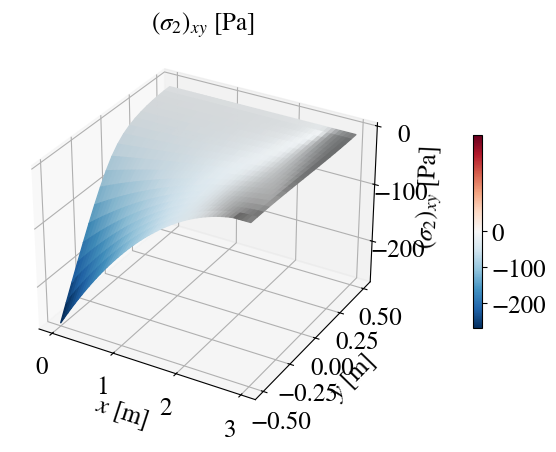

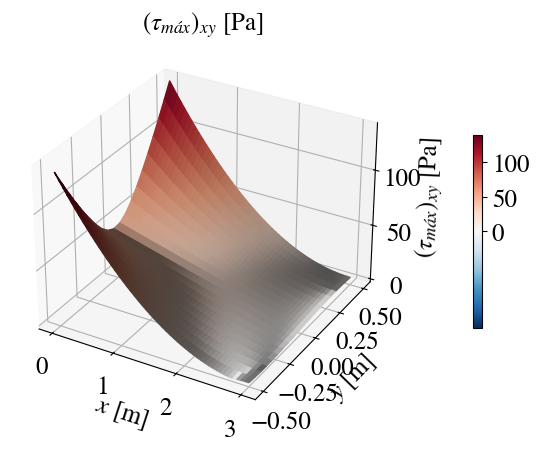

In [39]:
# Veamos la superficie del campo escalar de cada esfuerzo principal.
plot_3d_esf_def(x, y, s1,   r"$(\sigma_1)_{xy}$ [Pa]")
plot_3d_esf_def(x, y, s2,   r"$(\sigma_2)_{xy}$ [Pa]")
plot_3d_esf_def(x, y, tmax, r"$(\tau_{máx})_{xy}$ [Pa]")

## Diagramas de fuerza cortante y momento flector

Adicionalmente, podemos obtener los diagramas de fuerza cortante y momento flector
asociados, a partir de las siguientes ecuaciones:

$$V(x) = -\iint \tau_{xy}(x, y, z) \, dy \, dz = q(x - L)$$

$$M(x) = -\iint y\sigma_x(x, y, z) \, dy \, dz = \frac{q}{2}\left(x - L\right)^2$$

Estas ecuaciones fueron calculadas en el siguiente código: [4_10_4_relacion_esf_V_M_viga_voladizo.ipynb](https://github.com/michaelherediaperez/medio-continuo/blob/main/codigos/cap_04/4_10_4_relacion_esf_V_M_viga_voladizo.ipynb)

In [40]:
# Dominio 1D a lo largo de la luz: x ∈ [-L, L]
nx = 400
x1d = np.linspace(-L, L, nx)

# Funciones internas
V = -L*q + q*x1d
M = L**2*q/2 - L*q*x1d + q*x1d**2/2

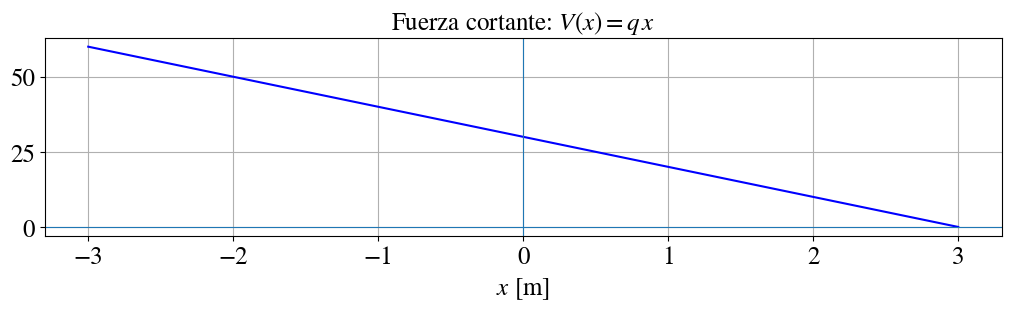

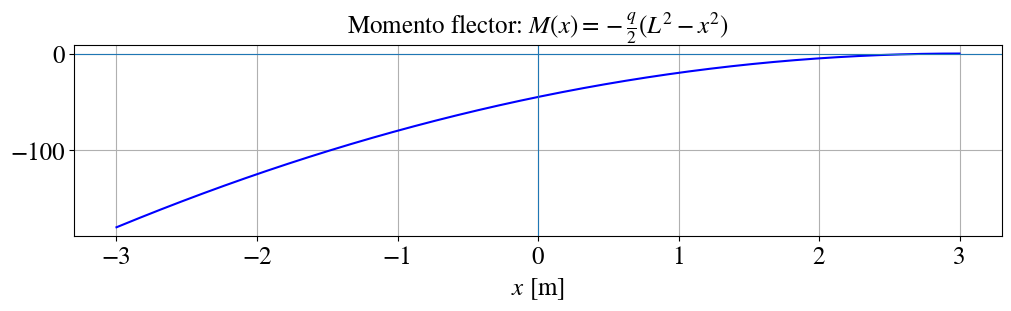

In [41]:
plot_v_m(x1d, V, r"Fuerza cortante: $V(x)=q\,x$")
plot_v_m(x1d, M, r"Momento flector: $M(x)=-\frac{q}{2}\left(L^2-x^2\right)$")

## Trayectorias de los esfuerzos

Las trayectorias de los esfuerzos principales $(\sigma_1)_{xy}$ y $(\sigma_2)_{xy}$, también llamadas *líneas isostáticas*, son la solución del siguiente par de ecuacioens diferenciales:

$$
\frac{dy}{dx}
=
-\frac{\sigma_x-\sigma_y}{2\tau_{xy}}
\;\pm\;
\sqrt{
\left(\frac{\sigma_x-\sigma_y}{2\tau_{xy}}\right)^2
+1
};
\qquad
$$

cuya característica es que son mutuamente ortogonales entre si.

In [42]:
# Se definen los esfuerzos (en tensión plana: sz = txz = tyz = 0)
# Solución de la función de tensión de Airy para una viga en voladizo
sx  = lambda x, y: -(q*y * (15*L**2 - 30*L*x + 6*c**2 + 15*x**2 - 10*y**2)) / (20*c**3)
sy  = lambda x, y: -(q * (-2*c + y) * (c + y)**2) / (4*c**3)
txy = lambda x, y:  (3*q * (-L + x) * (-c + y) * (c + y)) / (4*c**3)

In [43]:
# Término común a ambas ecuaciones diferenciales de las líneas isostáticas
R   = lambda x, y: -(sx(x,y) - sy(x,y)) / (2*txy(x,y))
H   = lambda x, y: np.hypot(1, (sx(x,y) - sy(x,y)) / (2*txy(x,y)))

dydxf1 = lambda x, y: R(x,y) + H(x,y)   # Trayectorias de tracción
dydxf2 = lambda x, y: R(x,y) - H(x,y)   # Trayectorias de compresión

In [44]:
from scipy.integrate import solve_ivp

# Intervalo de integración (solo mitad derecha, la izquierda se obtiene por simetría)
dominio = [0.001, L]
yini1   = np.linspace(-(c-0.001),  -0.001, 15)   # Condiciones iniciales: tracción
yini2   = np.linspace(  0.001,   c-0.001,  15)   # Condiciones iniciales: compresión

# Se resuelven las EDOs (LSODA por ser sistema stiff)
trayectorias = [
    solve_ivp(dydxf1, dominio, yini1, method='LSODA'),  # Tracción
    solve_ivp(dydxf2, dominio, yini2, method='LSODA'),  # Compresión
]
(x1, y1), (x2, y2) = [(sol.t, sol.y.T) for sol in trayectorias]

/tmp/ipykernel_26539/873489020.py:2: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_26539/873489020.py:3: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_26539/3015934013.py:5: RuntimeWarning:

invalid value encountered in multiply



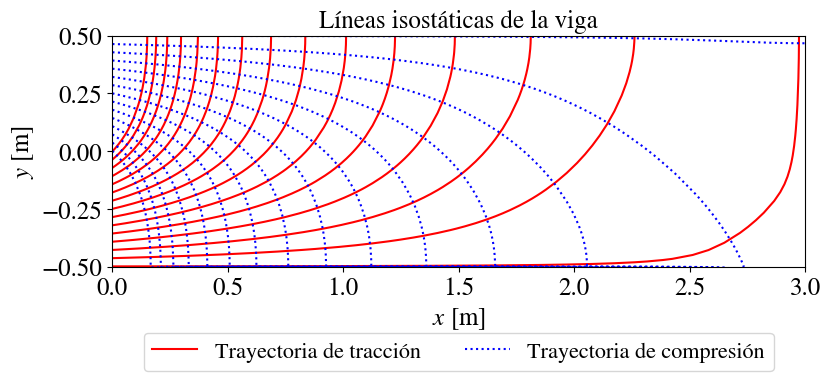

In [45]:
fig, ax = plt.subplots(figsize=(10, 3))

h1 = ax.plot( x1, y1, 'r-', label='Trayectoria de tracción')[0]
h2 = ax.plot( x2, y2, 'b:', label='Trayectoria de compresión')[0]

ax.set_aspect('equal')
ax.axis([-0, L, -c, c])
ax.legend(handles=[h1, h2], loc='lower center', bbox_to_anchor=(0.5, -0.5), ncols=2)

# Se especifican los ejes y el título, y se colocan los ejes iguales.
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]", rotation = 90)
ax.set_title("Líneas isostáticas de la viga")

plt.show()

Fin :)